LLM-as-a-judge eval

In [2]:
import os
import pandas as pd

In [3]:
file_names = []

for path, folder, files in os.walk("Source Files (Human Evaluation) Backup"):
    if not folder:
        for each in files:
            file_names.append(each.replace(".json", f"-{path.split('/')[-1].lower().replace(' ', '-')}.json"))

In [4]:
human_batch_interview_map = {}

In [5]:
for each_name in file_names:
    file_name_split = each_name.split(".")[0].split("_interview_")
    actual_file_name = file_name_split[0]
    interview_number = int(file_name_split[1].split("-batch-")[0])
    batch_number = int(file_name_split[1].split("-batch-")[1])
    if batch_number not in human_batch_interview_map:
        human_batch_interview_map[batch_number] = {}
    human_batch_interview_map[batch_number][interview_number] = actual_file_name

In [6]:
# Define paths and sheet names
file_path_1 = "Human vs. AI Interviews Code/Human vs. AI Interviews.xlsx"
file_path_2 = "Human vs. AI Interviews Code/[Responses] Human Evals for AI vs. Human interviews.xlsx"

In [9]:
file_path_1 = "Human vs. AI Interviews.xlsx"
file_path_2 = "[Responses] Human Evals for AI vs. Human interviews.xlsx"

In [10]:
# Define a list of sheet names to read from the Excel file
sheet_names_1 = ["human round 1", "human round 2", "human round 3", "human round 4", "human round 5", 
"ai round 1", "ai round 2", "ai round 3", "ai round 4", "ai round 5"]

sheet_names_2 = ["human evaluation - batch 1", "human evaluation - batch 2", "human evaluation - batch 3", "human evaluation - batch 4", "human evaluation - batch 5", 
"human evaluation - batch 6", "human evaluation - batch 7"]

In [11]:

# Use a dictionary comprehension to read each sheet into a DataFrame
# The key in the dictionary is the sheet name, and the value is the corresponding DataFrame
dataframes_ai_eval = {sheet: pd.read_excel(file_path_1, sheet_name=sheet) for sheet in sheet_names_1}
dataframes_human_eval = {sheet: pd.read_excel(file_path_2, sheet_name=sheet) for sheet in sheet_names_2}

In [12]:
for sheet, df in dataframes_human_eval.items():
    batch_number = int(sheet.split()[-1])
    df["batch_number"] = [batch_number] * len(df)

In [13]:
final_ai_dataframe = pd.concat(dataframes_ai_eval.values(), ignore_index=True)
final_human_dataframe = pd.concat(dataframes_human_eval.values(), ignore_index=True)

In [14]:
print(len(final_ai_dataframe), len(final_human_dataframe))

5750 70


In [15]:
final_ai_dataframe.head(5)

,interview_id,conversational_quality_overall_score,technical_quality_overall_score,conversational_quality_dialogue_flow,conversational_quality_response_building,conversational_quality_acknowledgement,technical_quality_skill_alignment,technical_quality_logical_progression,technical_quality_question_clarity,original_index
0,GMT20241019-153125_Recording,5.5,7.8,6.5,5.8,4.2,8.2,7.8,7.5,NaN
1,GMT20240914-160813_Recording,3.5,8.0,4.5,3.8,2.9,8.5,7.8,8.2,NaN
2,GMT20241019-143231_Recording,4.5,8.0,5.8,4.2,3.5,8.5,7.8,8.2,NaN
3,GMT20240819-123232_Recording,5.5,8.4,6.5,5.8,4.2,8.7,8.2,7.8,NaN
4,GMT20240321-163309_Recording,7.0,5.5,6.5,7.2,7.8,5.8,4.5,6.2,NaN


In [16]:
final_human_dataframe.head(5)

,interview_id,conversational_quality_overall_score,technical_quality_overall_score,conversational_quality_dialogue_flow,conversational_quality_response_building,conversational_quality_acknowledgement,technical_quality_skill_alignment,technical_quality_logical_progression,technical_quality_question_clarity,batch_number
0,1,8.5,9.0,8,8.0,9.0,9.0,8.0,10.0,1
1,2,6.0,6.0,7,6.0,5.0,8.0,6.0,9.0,1
2,3,6.0,8.0,6,6.0,6.0,10.0,7.0,10.0,1
3,4,8.0,8.5,7,8.0,8.0,8.0,8.0,10.0,1
4,5,9.0,9.0,8,8.5,9.0,9.0,9.0,9.0,1


In [17]:
final_human_dataframe["interview_id_name"] = final_human_dataframe.apply(lambda row:human_batch_interview_map[int(row["batch_number"])][int(row["interview_id"])], axis=1)

In [18]:
final_human_dataframe.head(5)

,interview_id,conversational_quality_overall_score,technical_quality_overall_score,conversational_quality_dialogue_flow,conversational_quality_response_building,conversational_quality_acknowledgement,technical_quality_skill_alignment,technical_quality_logical_progression,technical_quality_question_clarity,batch_number,interview_id_name
0,1,8.5,9.0,8,8.0,9.0,9.0,8.0,10.0,1,vLlCaAvjWXPB
1,2,6.0,6.0,7,6.0,5.0,8.0,6.0,9.0,1,UkPYhfwO3GZn
2,3,6.0,8.0,6,6.0,6.0,10.0,7.0,10.0,1,n6waAXDWlrj6
3,4,8.0,8.5,7,8.0,8.0,8.0,8.0,10.0,1,lpCqX0EnTFzw
4,5,9.0,9.0,8,8.5,9.0,9.0,9.0,9.0,1,ZIc55ure983O


In [19]:
file_names = final_human_dataframe["interview_id_name"].to_list()

In [20]:
filtered_ai_dataframe = final_ai_dataframe[final_ai_dataframe["interview_id"].isin(file_names)]

In [21]:
filtered_ai_dataframe = filtered_ai_dataframe.sort_values(by="interview_id").drop_duplicates(subset="interview_id", keep="first")
print(len(filtered_ai_dataframe))

67


In [22]:
from collections import Counter
file_name_counts = Counter(file_names)
duplicates = {key: value for key, value in file_name_counts.items() if value > 1}
print(duplicates.keys())

dict_keys(['hNvB8OPoKB1E', 'GMT20241005-113209_Recording', '4Tp7z1DIJhlI'])


In [23]:
append_interview_ids = list(duplicates.keys())
records_to_append = filtered_ai_dataframe[filtered_ai_dataframe['interview_id'].isin(append_interview_ids)]
print(len(records_to_append))
final_ai_dataframe_with_appended = pd.concat([filtered_ai_dataframe, records_to_append], ignore_index=True)
print(len(final_ai_dataframe_with_appended))


3
70


### Final Dataframes are final_human_dataframe and final_ai_dataframe_with_appended

In [24]:
sorted_human_df = final_human_dataframe.sort_values(by="interview_id_name").reset_index(drop=True)
sorted_ai_df = final_ai_dataframe_with_appended.sort_values(by="interview_id").reset_index(drop=True)

# Zip records from both DataFrames based on the index and create tuples
zipped_records = list(zip(sorted_human_df.to_dict('records'), sorted_ai_df.to_dict('records')))
final_dict_list = []
# Display the resulting tuples
for human, ai in zipped_records:
    temp_dict = {}
    temp_dict["human_interview_id"] = human["interview_id"]
    temp_dict["human_interview_batch"] = human["batch_number"]
    temp_dict["human_interview_name"] = human["interview_id_name"]
    temp_dict["human_conversational_quality_overall_score"] = human["conversational_quality_overall_score"]
    temp_dict["human_technical_quality_overall_score"] = human["technical_quality_overall_score"]
    temp_dict["ai_conversational_quality_overall_score"] = ai["conversational_quality_overall_score"]
    temp_dict["ai_technical_quality_overall_score"] = ai["technical_quality_overall_score"]
    temp_dict["ai_interview_name"] = ai["interview_id"]
    final_dict_list.append(temp_dict)

In [25]:
final_df = pd.DataFrame(final_dict_list, columns=list(final_dict_list[0].keys()))

In [26]:
list_of_tuples = list(zip(final_df["human_interview_name"], final_df["ai_interview_name"]))

In [27]:
for val in list_of_tuples:
    if val[0] != val[1]:
        print(val)

In [28]:
final_df["data_label"] = final_df.apply(lambda row:f"interview_{row['human_interview_batch']}_{row['human_interview_id']}", axis=1)

In [29]:
final_df.head(10)

,human_interview_id,human_interview_batch,human_interview_name,human_conversational_quality_overall_score,human_technical_quality_overall_score,ai_conversational_quality_overall_score,ai_technical_quality_overall_score,ai_interview_name,data_label
0,4,4,10GIxJEamI4X,9.0,9.0,8.4,8.8,10GIxJEamI4X,interview_4_4
1,2,5,1t5RUdUv4fI1,7.0,8.5,7.8,8.2,1t5RUdUv4fI1,interview_5_2
2,4,3,4Tp7z1DIJhlI,8.0,8.0,7.8,8.8,4Tp7z1DIJhlI,interview_3_4
3,3,5,4Tp7z1DIJhlI,8.0,8.5,7.8,8.8,4Tp7z1DIJhlI,interview_5_3
4,2,3,57IhGMATPVQX,8.0,9.0,7.0,8.0,57IhGMATPVQX,interview_3_2
5,3,7,7hP15ISNb0vH,8.0,8.5,7.0,7.8,7hP15ISNb0vH,interview_7_3
6,1,4,7hdvtxhALe9p,9.0,8.0,8.0,8.7,7hdvtxhALe9p,interview_4_1
7,2,2,83PIsa43uTdj,8.0,7.0,7.8,8.0,83PIsa43uTdj,interview_2_2
8,5,5,F4Uwf01UuLzN,8.5,8.5,8.4,8.8,F4Uwf01UuLzN,interview_5_5
9,9,2,GMT20240410-133003_Recording,3.0,4.0,3.5,5.2,GMT20240410-133003_Recording,interview_2_9


In [30]:
final_df.columns

Index(['human_interview_id', 'human_interview_batch', 'human_interview_name',
       'human_conversational_quality_overall_score',
       'human_technical_quality_overall_score',
       'ai_conversational_quality_overall_score',
       'ai_technical_quality_overall_score', 'ai_interview_name',
       'data_label'],
      dtype='object')

In [31]:
sorted_df = final_df.sort_values(by=['human_interview_batch', 'human_interview_id']).reset_index(drop=True)



In [32]:
print(sorted_df["ai_conversational_quality_overall_score"].mean())
print(sorted_df["human_conversational_quality_overall_score"].mean())
print("\n\n")
print(sorted_df["ai_technical_quality_overall_score"].mean())
print(sorted_df["human_technical_quality_overall_score"].mean())

6.4385714285714295
7.045714285714285



8.058571428571428
7.607142857142857


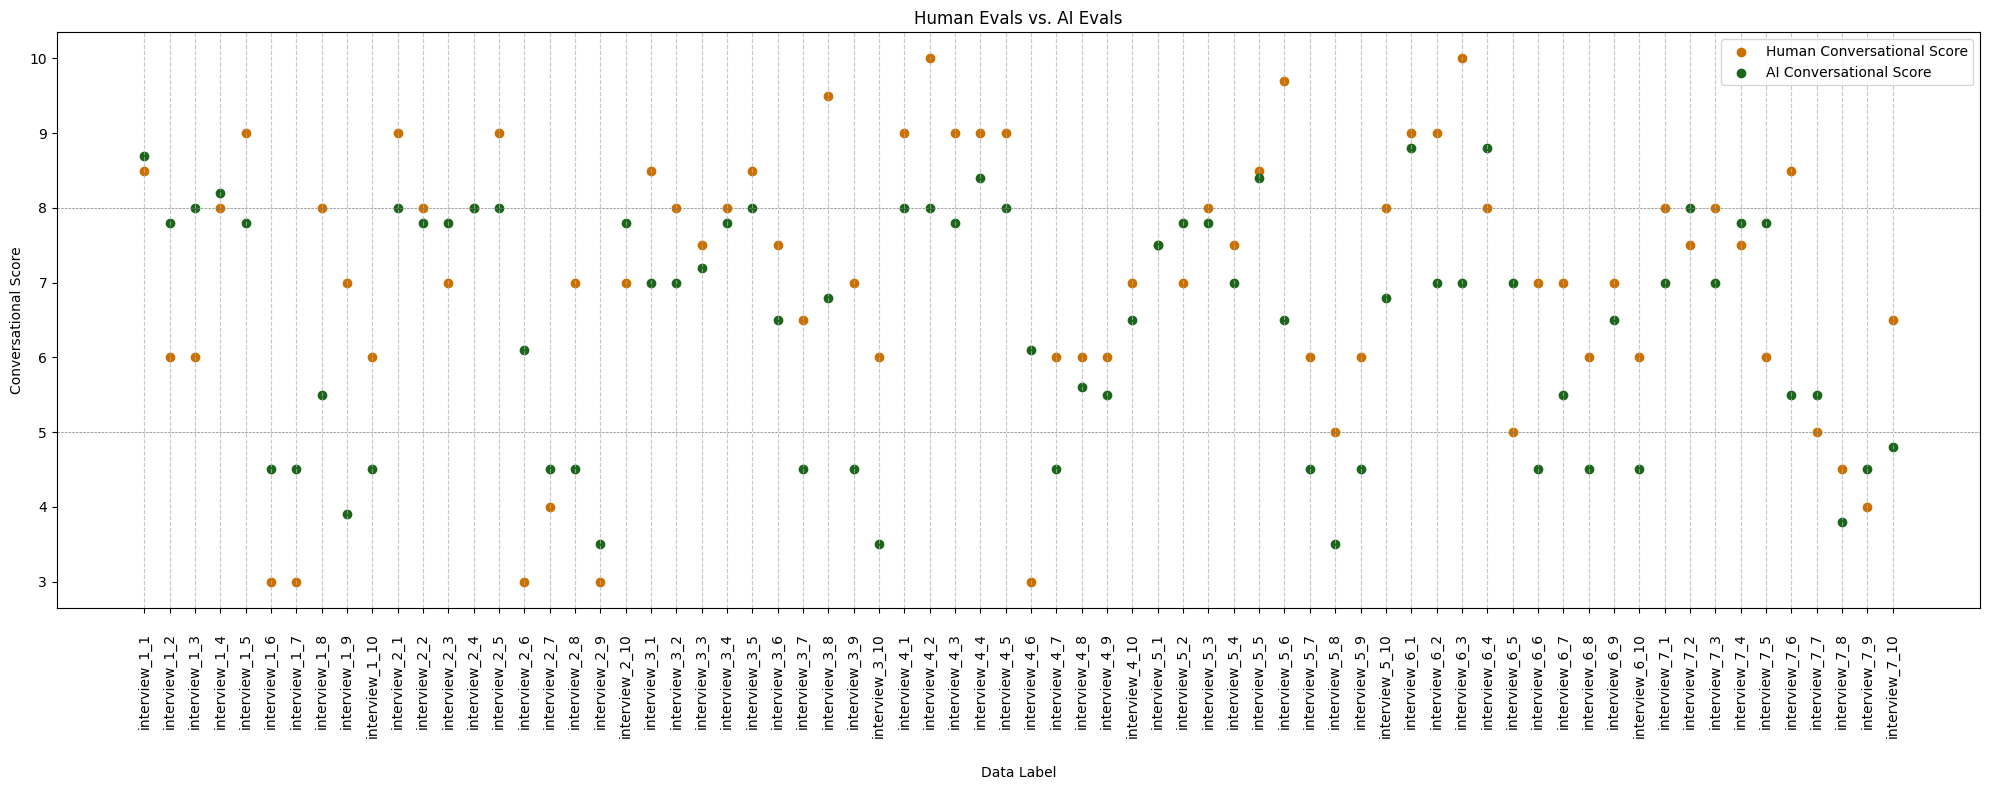

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 8))  # Increase figure size for better spacing

['#2E3D44', '#388E3C']
# Scatter plot for Conversational Quality
plt.scatter(sorted_df['data_label'], sorted_df['human_conversational_quality_overall_score'], label='Human Conversational Score', color='#CC7000')
plt.scatter(sorted_df['data_label'], sorted_df['ai_conversational_quality_overall_score'], label='AI Conversational Score', color='#1A661A')

# Add horizontal dashed lines
plt.axhline(y=5, color='gray', linestyle='--', linewidth=0.5)
plt.axhline(y=8, color='gray', linestyle='--', linewidth=0.5)

# Rotate x-ticks
plt.xticks(sorted_df['data_label'], rotation=90, fontsize=10, ha='center', va='top')
plt.gca().tick_params(axis='x', pad=15)

# Add vertical gridlines
plt.grid(True, axis='x', linestyle='--', alpha=0.7)

# Add labels and title
plt.xlabel('Data Label', labelpad=20)
plt.ylabel('Conversational Score')
plt.title('Human Evals vs. AI Evals')
plt.legend()
plt.tight_layout()
plt.show()


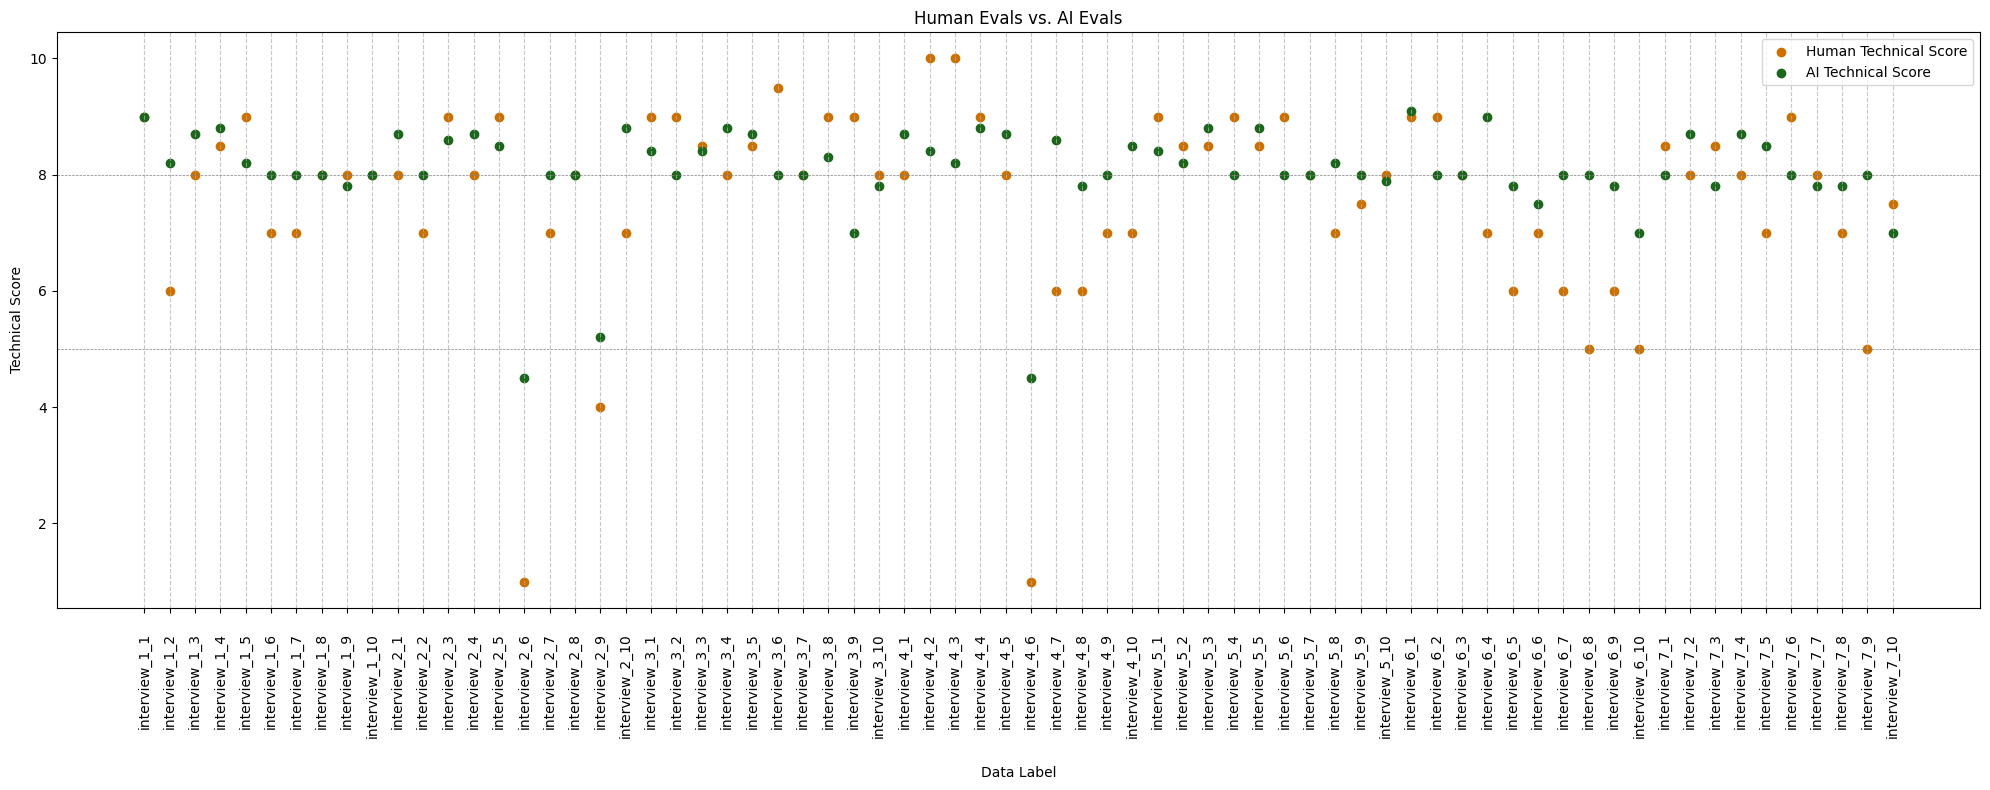

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 8))  # Increase figure size for better spacing

# Scatter plot for Technical Quality
plt.scatter(sorted_df['data_label'], sorted_df['human_technical_quality_overall_score'], label='Human Technical Score', color='#CC7000')
plt.scatter(sorted_df['data_label'], sorted_df['ai_technical_quality_overall_score'], label='AI Technical Score', color='#1A661A')

# Add horizontal dashed lines
plt.axhline(y=5, color='gray', linestyle='--', linewidth=0.5)
plt.axhline(y=8, color='gray', linestyle='--', linewidth=0.5)

# Rotate x-ticks
plt.xticks(sorted_df['data_label'], rotation=90, fontsize=10, ha='center', va='top')
plt.gca().tick_params(axis='x', pad=15)

# Add vertical gridlines
plt.grid(True, axis='x', linestyle='--', alpha=0.7)

# Add labels and title
plt.xlabel('Data Label', labelpad=20)
plt.ylabel('Technical Score')
plt.title('Human Evals vs. AI Evals')
plt.legend()
plt.tight_layout()
plt.show()


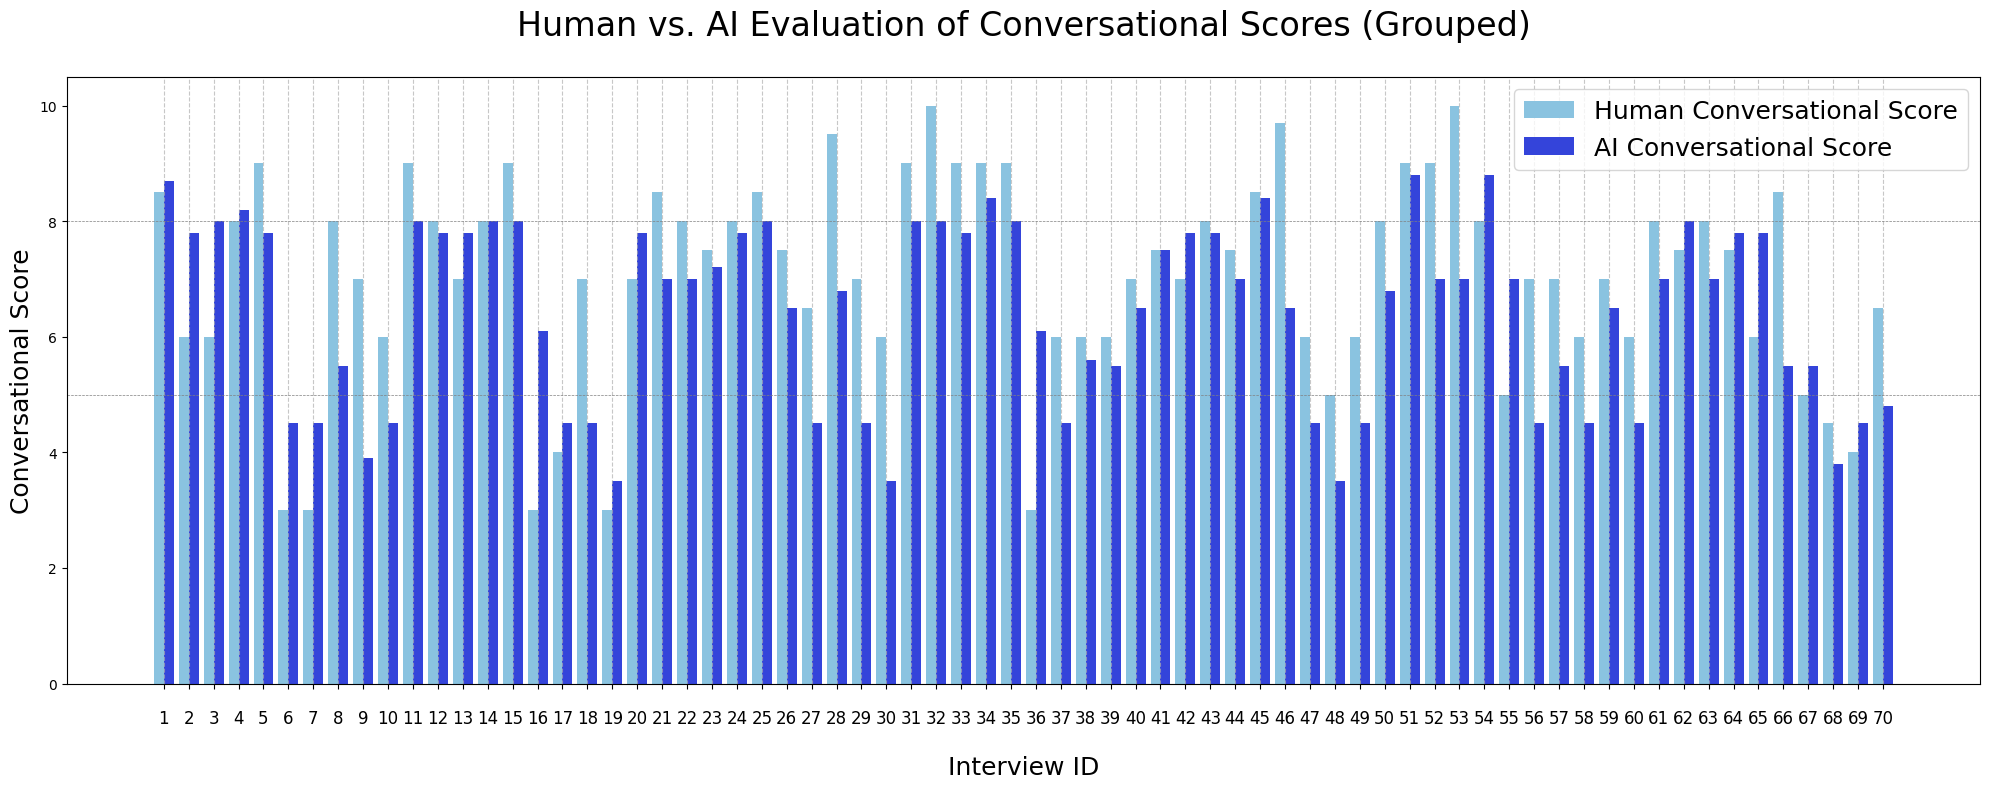

In [35]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 8))  # Same figure size as the scatter plot

# Prepare data for grouped bar chart
# x_labels = sorted_df['data_label']
x_labels = list(range(1, 71))
x = np.arange(len(x_labels))  # Label locations
width = 0.4  # Width of the bars

# Bar chart for Human and AI Conversational Scores
plt.bar(x - width/2, sorted_df['human_conversational_quality_overall_score'], width, label='Human Conversational Score', color='#8AC3E0')
plt.bar(x + width/2, sorted_df['ai_conversational_quality_overall_score'], width, label='AI Conversational Score', color='#3444DA')

# Add horizontal dashed lines
plt.axhline(y=5, color='gray', linestyle='--', linewidth=0.5)
plt.axhline(y=8, color='gray', linestyle='--', linewidth=0.5)

# Add x-ticks with rotation
plt.xticks(x, x_labels, fontsize=12, ha='center', va='top')
plt.gca().tick_params(axis='x', pad=15)

# Add vertical gridlines
plt.grid(True, axis='x', linestyle='--', alpha=0.7)

# Add labels, title, and legend
plt.xlabel('Interview ID', labelpad=20, fontsize=18)
plt.ylabel('Conversational Score', fontsize=18)
plt.title('Human vs. AI Evaluation of Conversational Scores (Grouped)', pad=30, fontsize=24)
plt.legend(fontsize=18)
plt.tight_layout()
plt.show()


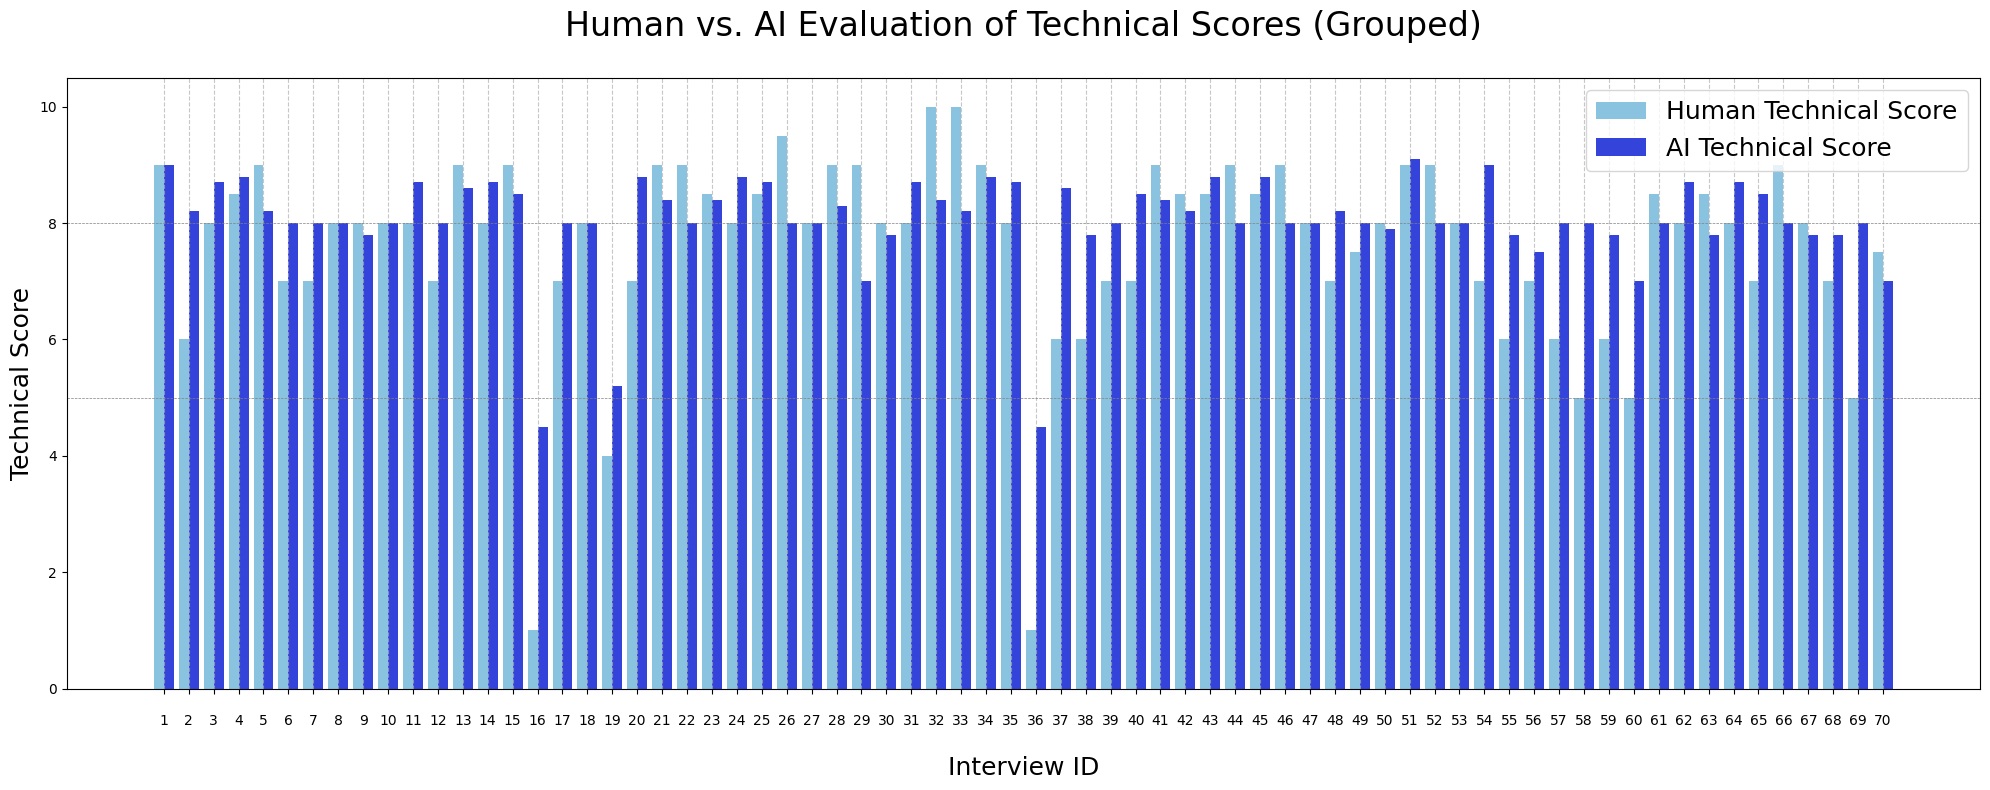

In [36]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 8))  # Same figure size as the conversational plot

# Prepare data for grouped bar chart
# x_labels = sorted_df['data_label']
x_labels = list(range(1, 71))
x = np.arange(len(x_labels))  # Label locations
width = 0.4  # Width of the bars

# Bar chart for Human and AI Technical Scores
plt.bar(x - width/2, sorted_df['human_technical_quality_overall_score'], width, label='Human Technical Score', color='#8AC3E0')
plt.bar(x + width/2, sorted_df['ai_technical_quality_overall_score'], width, label='AI Technical Score', color='#3444DA')

# Add horizontal dashed lines
plt.axhline(y=5, color='gray', linestyle='--', linewidth=0.5)
plt.axhline(y=8, color='gray', linestyle='--', linewidth=0.5)

# Add x-ticks with rotation
plt.xticks(x, x_labels, fontsize=10, ha='center', va='top')
plt.gca().tick_params(axis='x', pad=15)

# Add vertical gridlines
plt.grid(True, axis='x', linestyle='--', alpha=0.7)

# Add labels, title, and legend
plt.xlabel('Interview ID', labelpad=20, fontsize=18)
plt.ylabel('Technical Score', fontsize=18)
plt.title('Human vs. AI Evaluation of Technical Scores (Grouped)', pad=30, fontsize=24)
plt.legend(fontsize=18)
plt.tight_layout()
plt.show()


In [37]:
sorted_df.head()

,human_interview_id,human_interview_batch,human_interview_name,human_conversational_quality_overall_score,human_technical_quality_overall_score,ai_conversational_quality_overall_score,ai_technical_quality_overall_score,ai_interview_name,data_label
0,1,1,vLlCaAvjWXPB,8.5,9.0,8.7,9.0,vLlCaAvjWXPB,interview_1_1
1,2,1,UkPYhfwO3GZn,6.0,6.0,7.8,8.2,UkPYhfwO3GZn,interview_1_2
2,3,1,n6waAXDWlrj6,6.0,8.0,8.0,8.7,n6waAXDWlrj6,interview_1_3
3,4,1,lpCqX0EnTFzw,8.0,8.5,8.2,8.8,lpCqX0EnTFzw,interview_1_4
4,5,1,ZIc55ure983O,9.0,9.0,7.8,8.2,ZIc55ure983O,interview_1_5


In [38]:
sorted_df_human_con_mean = sorted_df["human_conversational_quality_overall_score"].mean()
sorted_df_human_tech_mean = sorted_df["human_technical_quality_overall_score"].mean()
sorted_df_ai_con_mean = sorted_df["ai_conversational_quality_overall_score"].mean()
sorted_df_ai_tech_mean = sorted_df["ai_technical_quality_overall_score"].mean()

sorted_df_human_con_max = sorted_df["human_conversational_quality_overall_score"].max()
sorted_df_human_tech_max = sorted_df["human_technical_quality_overall_score"].max()
sorted_df_ai_con_max = sorted_df["ai_conversational_quality_overall_score"].max()
sorted_df_ai_tech_max = sorted_df["ai_technical_quality_overall_score"].max()

sorted_df_human_con_min = sorted_df["human_conversational_quality_overall_score"].min()
sorted_df_human_tech_min = sorted_df["human_technical_quality_overall_score"].min()
sorted_df_ai_con_min = sorted_df["ai_conversational_quality_overall_score"].min()
sorted_df_ai_tech_min = sorted_df["ai_technical_quality_overall_score"].min()


In [39]:
sorted_df["human_conversational_quality_overall_score_normalized"] = sorted_df["human_conversational_quality_overall_score"].apply(lambda x: round((x - sorted_df_human_con_mean)/(sorted_df_human_con_max - sorted_df_human_con_min), 2))
sorted_df["human_technical_quality_overall_score_normalized"] = sorted_df["human_technical_quality_overall_score"].apply(lambda x: round((x - sorted_df_human_tech_mean)/(sorted_df_human_tech_max - sorted_df_human_tech_min), 2))
sorted_df["ai_conversational_quality_overall_score_normalized"] = sorted_df["ai_conversational_quality_overall_score"].apply(lambda x: round((x - sorted_df_ai_con_mean)/(sorted_df_ai_con_max - sorted_df_ai_con_min), 2))
sorted_df["ai_technical_quality_overall_score_normalized"] = sorted_df["ai_technical_quality_overall_score"].apply(lambda x: round((x - sorted_df_ai_tech_mean)/(sorted_df_ai_tech_max - sorted_df_ai_tech_min), 2))

In [45]:
# sorted_df["human_conversational_quality_overall_score_normalized"] = sorted_df["human_conversational_quality_overall_score"].apply(
#     lambda x: round((x - sorted_df_human_con_min) / (sorted_df_human_con_max - sorted_df_human_con_min), 2)
# )

# sorted_df["human_technical_quality_overall_score_normalized"] = sorted_df["human_technical_quality_overall_score"].apply(
#     lambda x: round((x - sorted_df_human_tech_min) / (sorted_df_human_tech_max - sorted_df_human_tech_min), 2)
# )

# sorted_df["ai_conversational_quality_overall_score_normalized"] = sorted_df["ai_conversational_quality_overall_score"].apply(
#     lambda x: round((x - sorted_df_ai_con_min) / (sorted_df_ai_con_max - sorted_df_ai_con_min), 2)
# )

# sorted_df["ai_technical_quality_overall_score_normalized"] = sorted_df["ai_technical_quality_overall_score"].apply(
#     lambda x: round((x - sorted_df_ai_tech_min) / (sorted_df_ai_tech_max - sorted_df_ai_tech_min), 2)
# )


# Columns you want to z-score
cols = [
    "human_conversational_quality_overall_score",
    "human_technical_quality_overall_score",
    "ai_conversational_quality_overall_score",
    "ai_technical_quality_overall_score",
]

for col in cols:
    mean = sorted_df[col].mean()
    std  = sorted_df[col].std(ddof=0)          # ddof=0 → population std; use 1 for sample std
    # Create a new column with z-scores, rounded to 2 decimals
    sorted_df[f"{col}_zscore"] = ((sorted_df[col] - mean) / std).round(2)


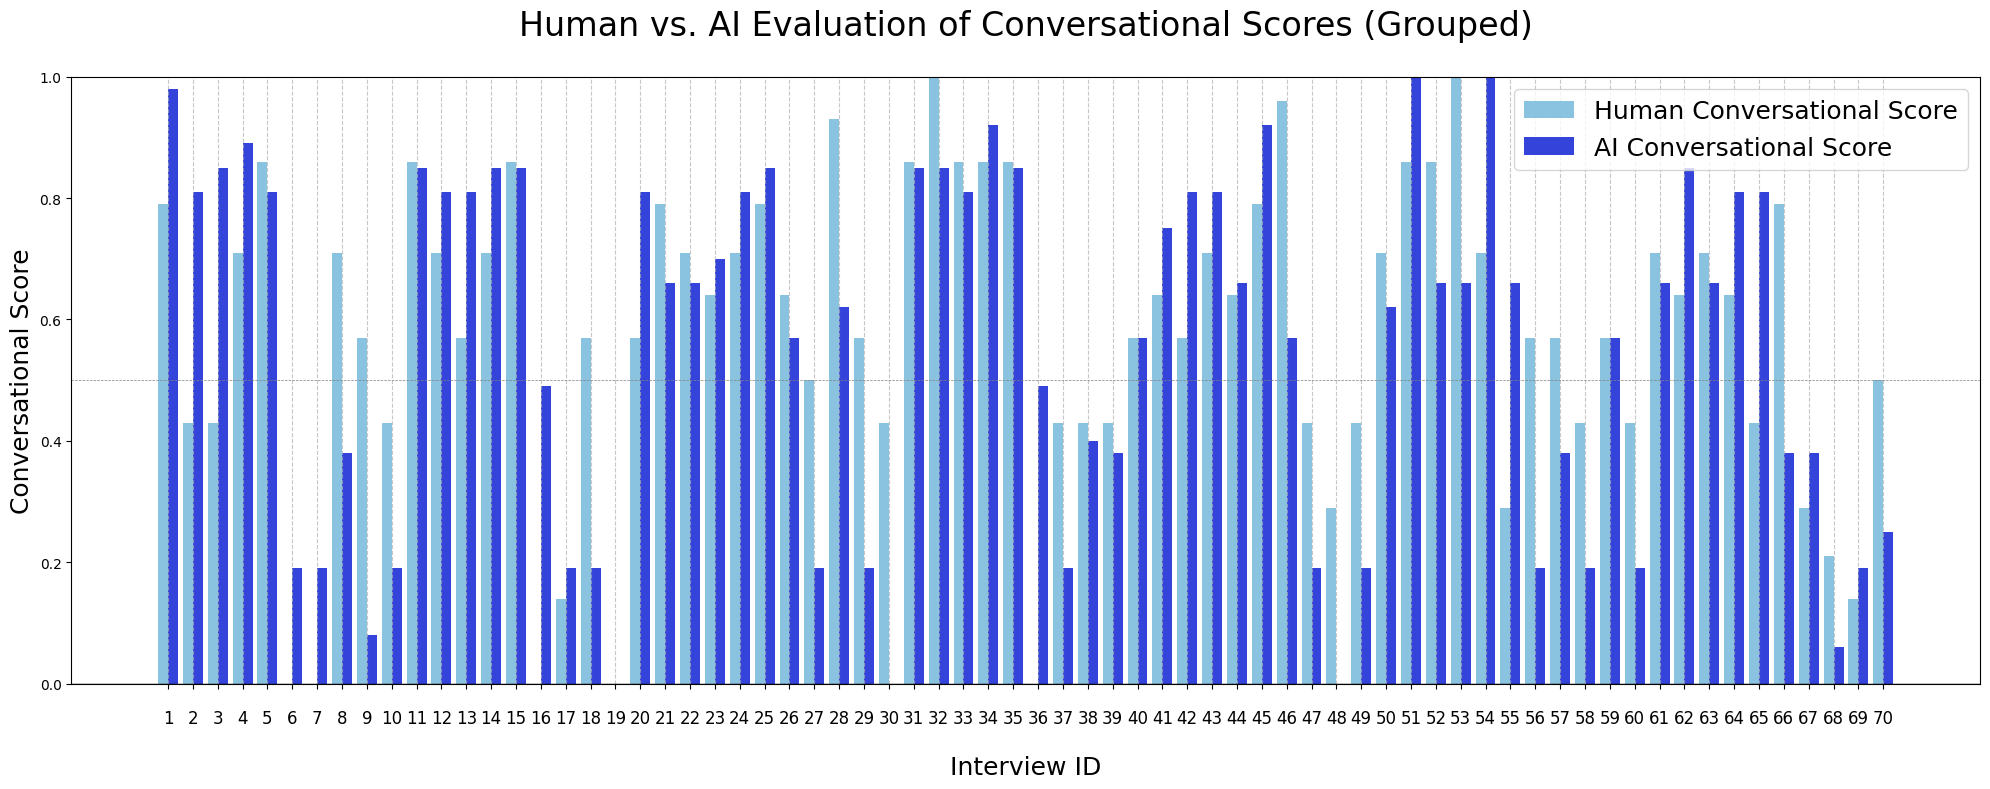

In [46]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 8))  # Same figure size as the scatter plot

# Prepare data for grouped bar chart
# x_labels = sorted_df['data_label']
x_labels = list(range(1, 71))
x = np.arange(len(x_labels))  # Label locations
width = 0.4  # Width of the bars

max_value = max(
    sorted_df['human_conversational_quality_overall_score_normalized'].max(), 
    sorted_df['ai_conversational_quality_overall_score_normalized'].max()
)

# Set y-limits from 0 to 1
plt.ylim(0, 1)

# Bar chart for Human and AI Conversational Scores
plt.bar(x - width/2, sorted_df['human_conversational_quality_overall_score_normalized'], width, label='Human Conversational Score', color='#8AC3E0')
plt.bar(x + width/2, sorted_df['ai_conversational_quality_overall_score_normalized'], width, label='AI Conversational Score', color='#3444DA')

plt.axhline(y=0, color='black', linestyle='-', linewidth=1)

# Add horizontal dashed lines
plt.axhline(y=max_value / 2, color='gray', linestyle='--', linewidth=0.5)
plt.axhline(y=max_value, color='gray', linestyle='--', linewidth=0.5)

# Add x-ticks with rotation
plt.xticks(x, x_labels, fontsize=12, ha='center', va='top')
plt.gca().tick_params(axis='x', pad=15)

# Add vertical gridlines
plt.grid(True, axis='x', linestyle='--', alpha=0.7)

# Add labels, title, and legend
plt.xlabel('Interview ID', labelpad=20, fontsize=18)
plt.ylabel('Conversational Score', fontsize=18)
plt.title('Human vs. AI Evaluation of Conversational Scores (Grouped)', pad=30, fontsize=24)
plt.legend(fontsize=18)
plt.tight_layout()
plt.show()


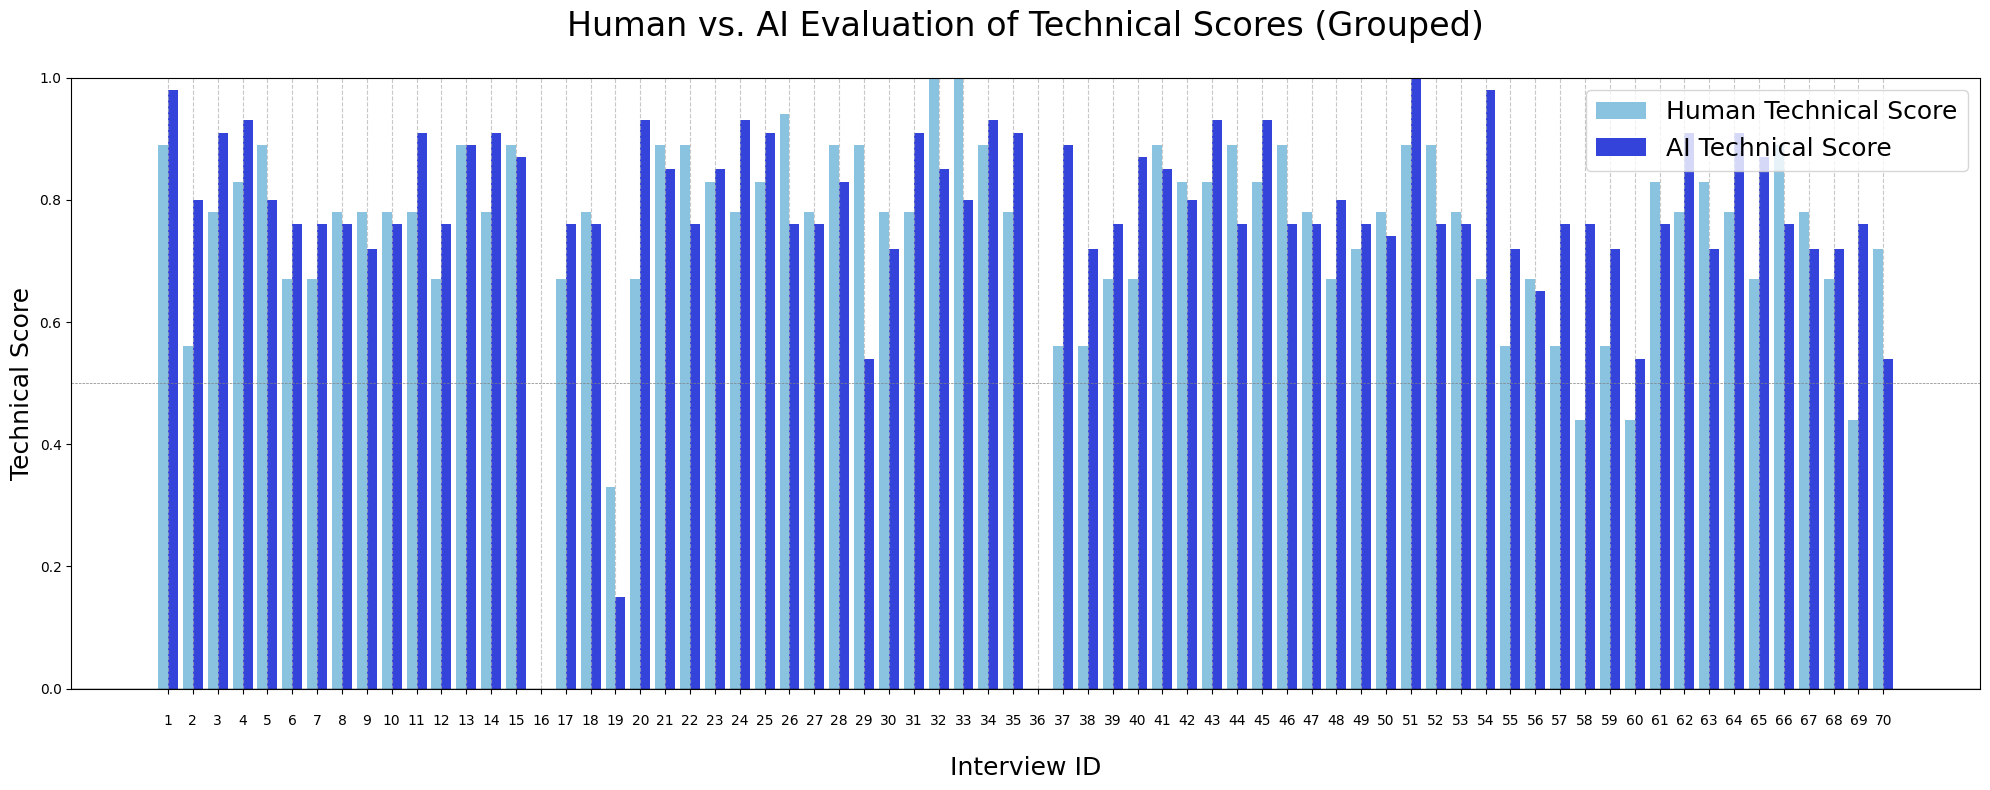

In [47]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 8))  # Same figure size as the conversational plot

# Prepare data for grouped bar chart
# x_labels = sorted_df['data_label']
x_labels = list(range(1, 71))
x = np.arange(len(x_labels))  # Label locations
width = 0.4  # Width of the bars

max_value = max(
    sorted_df['human_technical_quality_overall_score_normalized'].max(), 
    sorted_df['ai_technical_quality_overall_score_normalized'].max()
)

# Set y-limits from 0 to 1
plt.ylim(0, 1)

# Bar chart for Human and AI Technical Scores
plt.bar(x - width/2, sorted_df['human_technical_quality_overall_score_normalized'], width, label='Human Technical Score', color='#8AC3E0')
plt.bar(x + width/2, sorted_df['ai_technical_quality_overall_score_normalized'], width, label='AI Technical Score', color='#3444DA')

plt.axhline(y=0, color='black', linestyle='-', linewidth=1)

plt.axhline(y=max_value / 2, color='gray', linestyle='--', linewidth=0.5)
plt.axhline(y=max_value, color='gray', linestyle='--', linewidth=0.5)

# Add x-ticks with rotation
plt.xticks(x, x_labels, fontsize=10, ha='center', va='top')
plt.gca().tick_params(axis='x', pad=15)

# Add vertical gridlines
plt.grid(True, axis='x', linestyle='--', alpha=0.7)

# Add labels, title, and legend
plt.xlabel('Interview ID', labelpad=20, fontsize=18)
plt.ylabel('Technical Score', fontsize=18)
plt.title('Human vs. AI Evaluation of Technical Scores (Grouped)', pad=30, fontsize=24)
plt.legend(fontsize=18)
plt.tight_layout()
plt.show()


In [63]:
correlation_conversation = sorted_df["human_conversational_quality_overall_score_normalized"].corr(
    sorted_df["ai_conversational_quality_overall_score_normalized"]
)
print(correlation_conversation)

0.6420145307229117


In [64]:
correlation_technical = sorted_df["human_technical_quality_overall_score_normalized"].corr(
    sorted_df["ai_technical_quality_overall_score_normalized"]
)
print(correlation_technical)

0.7194269220871237


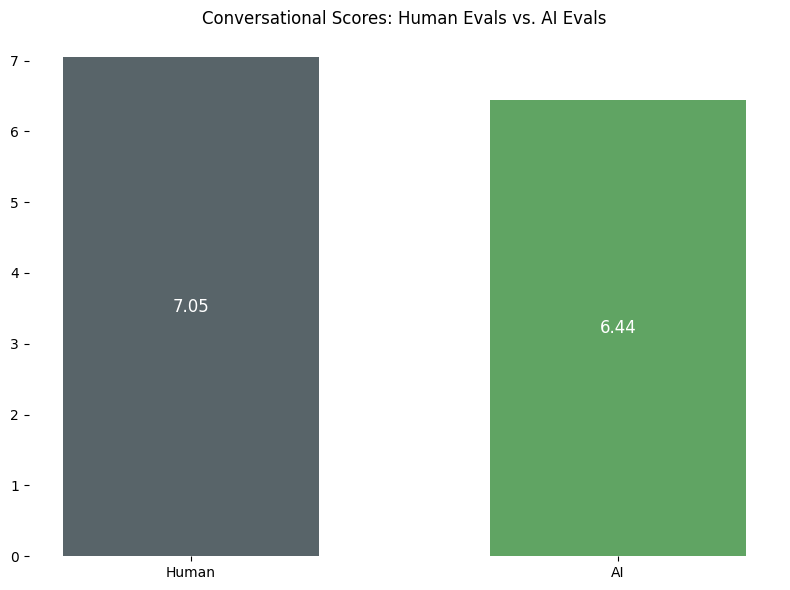

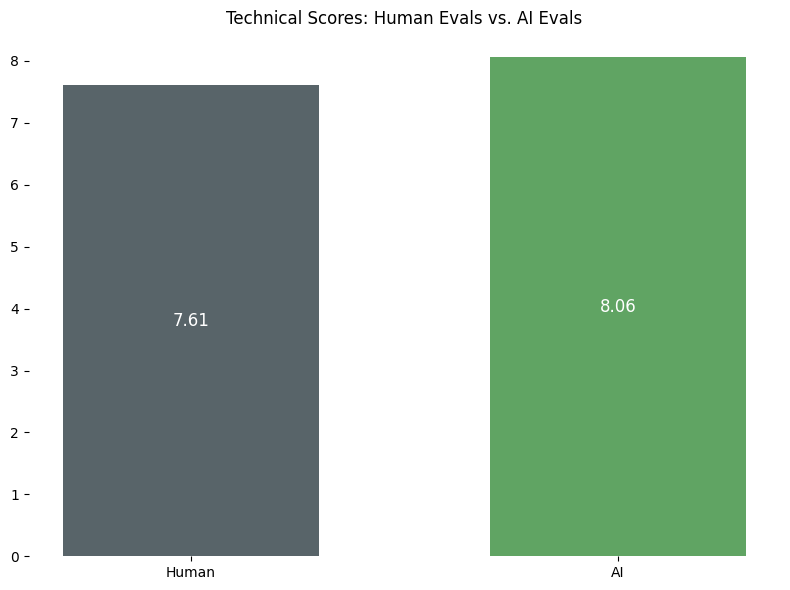

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Data for Conversational and Technical Scores
conversational_means = [
    sorted_df["human_conversational_quality_overall_score"].mean(),
    sorted_df["ai_conversational_quality_overall_score"].mean()
]
technical_means = [
    sorted_df["human_technical_quality_overall_score"].mean(),
    sorted_df["ai_technical_quality_overall_score"].mean()
]

# Labels and categories
categories_labels = ["Human", "AI"]
x = np.arange(len(categories_labels))  # Label locations

# Plot for Conversational Scores
plt.figure(figsize=(8, 6))  # Smaller width for closer bars
bars = plt.bar(x, conversational_means, width=0.6, color=['#2E3D44', '#388E3C'], alpha=0.8)

# Add mean values inside the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval / 2, f'{yval:.2f}', ha='center', va='center', color='white', fontsize=12)

# Remove outer borders
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)

plt.xticks(x, categories_labels)
plt.title("Conversational Scores: Human Evals vs. AI Evals")
plt.tight_layout()
plt.show()

# Plot for Technical Scores
plt.figure(figsize=(8, 6))  # Smaller width for closer bars
bars = plt.bar(x, technical_means, width=0.6, color=['#2E3D44', '#388E3C'], alpha=0.8)

# Add mean values inside the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval / 2, f'{yval:.2f}', ha='center', va='center', color='white', fontsize=12)

# Remove outer borders
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)

plt.xticks(x, categories_labels)
plt.title("Technical Scores: Human Evals vs. AI Evals")
plt.tight_layout()
plt.show()


In [34]:
ai_interview_names = sorted_df["ai_interview_name"].to_list()
file_name_counts = Counter(ai_interview_names)
duplicates = {key: value for key, value in file_name_counts.items() if value > 1}
print(duplicates.keys())

dict_keys(['hNvB8OPoKB1E', 'GMT20241005-113209_Recording', '4Tp7z1DIJhlI'])


In [35]:
duplicated_df = sorted_df[sorted_df["ai_interview_name"].isin(list(duplicates.keys()))]


In [36]:
duplicated_df.head(10)

,human_interview_id,human_interview_batch,human_interview_name,human_conversational_quality_overall_score,human_technical_quality_overall_score,ai_conversational_quality_overall_score,ai_technical_quality_overall_score,ai_interview_name,data_label
10,1,2,hNvB8OPoKB1E,9.0,8.0,8.0,8.7,hNvB8OPoKB1E,interview_2_1
15,6,2,GMT20241005-113209_Recording,3.0,1.0,6.1,4.5,GMT20241005-113209_Recording,interview_2_6
23,4,3,4Tp7z1DIJhlI,8.0,8.0,7.8,8.8,4Tp7z1DIJhlI,interview_3_4
34,5,4,hNvB8OPoKB1E,9.0,8.0,8.0,8.7,hNvB8OPoKB1E,interview_4_5
35,6,4,GMT20241005-113209_Recording,3.0,1.0,6.1,4.5,GMT20241005-113209_Recording,interview_4_6
42,3,5,4Tp7z1DIJhlI,8.0,8.5,7.8,8.8,4Tp7z1DIJhlI,interview_5_3


In [37]:
print(list(zip(duplicated_df["ai_interview_name"], duplicated_df["data_label"])))

[('hNvB8OPoKB1E', 'interview_2_1'), ('GMT20241005-113209_Recording', 'interview_2_6'), ('4Tp7z1DIJhlI', 'interview_3_4'), ('hNvB8OPoKB1E', 'interview_4_5'), ('GMT20241005-113209_Recording', 'interview_4_6'), ('4Tp7z1DIJhlI', 'interview_5_3')]


In [38]:
dd = {
    "interview_2_1" : "interview_4_5",
    "interview_2_6" : "interview_4_6",
    "interview_3_4" : "interview_5_3"
}

In [39]:
[(k, v) for k, v in dd.items()]

[('interview_2_1', 'interview_4_5'),
 ('interview_2_6', 'interview_4_6'),
 ('interview_3_4', 'interview_5_3')]

In [62]:
!pip install graphviz

In [114]:
from graphviz import Digraph

# Create a new directed graph with horizontal layout
dot = Digraph(format='png', engine='dot')
dot.attr(dpi='300', size='12,8', rankdir='LR')  # 'LR' for left-to-right layout


# Add the middle nodes to be split across two lines
dot.node('ResumeReview', 'Resume Review', fontsize='18', fontweight='bold', shape='rect')
dot.node('AdminMisc', 'Admin + Misc Tasks', fontsize='18', fontweight='bold', shape='rect')
dot.node('RecruiterInterview', 'Recruiter Interview', fontsize='18', fontweight='bold', shape='rect')
dot.node('EngineerInterview', 'Engineer Interview', fontsize='18', fontweight='bold', shape='rect')
dot.node('FinalHires', 'Final Hiring Decision', fontsize='18', fontweight='bold', shape='rect')



# Group the second set of nodes into another line (subgraph with rank='same')
with dot.subgraph() as s:
    s.attr(rank='same')
    s.node('EngineerInterview')
    s.node('FinalHires')

# Add edges (arrows between steps)
dot.edge('ResumeReview', 'AdminMisc')
dot.edge('AdminMisc', 'RecruiterInterview')
dot.edge('RecruiterInterview', 'EngineerInterview')
dot.edge('EngineerInterview', 'FinalHires')

# Render the flowchart
dot.render('manual_interview_process', view=True)


'manual_interview_process.png'

In [113]:
from graphviz import Digraph

# Create a new directed graph with horizontal layout
dot = Digraph(format='png', engine='dot')
dot.attr(dpi='300', size='12,8', rankdir='LR')  # 'LR' for left-to-right layout


# Add the middle nodes to be split across two lines
dot.node('InviteCandidates', 'Invite Candidates For \nInterview', fontsize='18', fontweight='bold', shape='rect')
dot.node('AIVetting', 'AI Vetting', fontsize='18', fontweight='bold', shape='rect')
dot.node('EngineerInterview', 'Engineer Interview', fontsize='18', fontweight='bold', shape='rect')
dot.node('FinalHires', 'Final Hiring Decision', fontsize='18', fontweight='bold', shape='rect')



# Add edges (arrows between steps)
dot.edge('InviteCandidates', 'AIVetting')
dot.edge('AIVetting', 'EngineerInterview')
dot.edge('EngineerInterview', 'FinalHires')

# Render the flowchart
dot.render('ai_interview_process', view=True)


'ai_interview_process.png'